In [1]:
import os
import sys
os.chdir("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_listings = pd.read_csv('data/combined_csvs/listings_property_vals.csv')

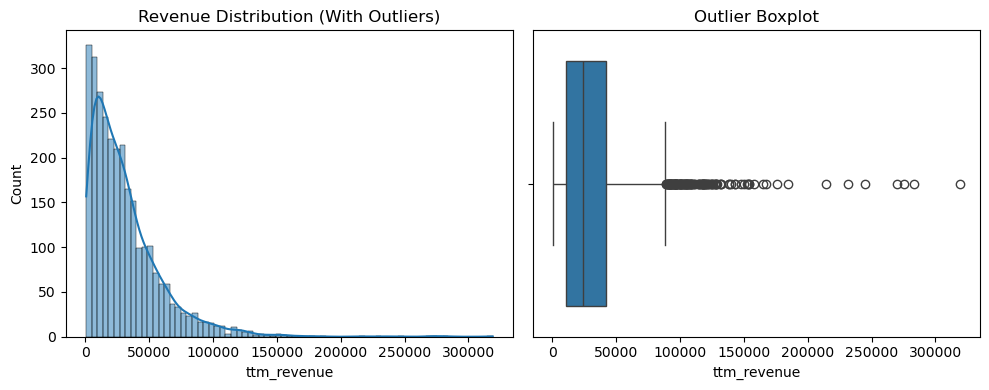

Lower bound: -36140.125, Upper bound: 88620.875
Removing rows outside this range. Total outliers: 127


In [3]:
# 1. Visualize the distribution and outliers
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df_listings["ttm_revenue"], kde=True)
plt.title("Revenue Distribution (With Outliers)")

plt.subplot(1, 2, 2)
sns.boxplot(x=df_listings["ttm_revenue"])
plt.title("Outlier Boxplot")
plt.tight_layout()
plt.show()

# 2. Calculate IQR thresholds
Q1 = df_listings["ttm_revenue"].quantile(0.25)
Q3 = df_listings["ttm_revenue"].quantile(0.75)
IQR = Q3 - Q1

# Define cutoffs (1.5 is standard, use 3.0 to target only extreme outliers)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")
print(
    f"Removing rows outside this range. Total outliers: "
    f"{((df_listings['ttm_revenue'] < lower_bound) | (df_listings['ttm_revenue'] > upper_bound)).sum()}"
)

# # 3. Filter the dataframe to remove the outliers
# df_clean = df_listings[
#     (df_listings["ttm_revenue"] >= lower_bound)
#     & (df_listings["ttm_revenue"] <= upper_bound)
# ]

In [ ]:
# Isolate the extreme upper-bound outliers
upper_outliers = df_listings[df_listings["ttm_revenue"] > upper_bound]

# Sort them from highest to lowest and look at the top 10
top_outliers = upper_outliers.sort_values(by="ttm_revenue", ascending=False)

# Display the top 10 rows with selected columns (add your actual column names here)
print(f"Total upper outliers detected: {len(upper_outliers)}")
top_outliers[[""]].head(50)  # Add columns like 'name' or 'id' to see context

Total upper outliers detected: 127


,listing_id,listing_name,description,listing_type,room_type,cover_photo_url,photos_count,photo_urls,host_id,host_name,...,l90d_reserved_days,l90d_blocked_days,l90d_available_days,l90d_total_days,city,Geocodio Address Line 1,zipcode,property_val,SizeRank,gross_yield
305,5891552,9 Bedroom•Indoor Pool• Chapel•Hot Tub•Arcade•G...,Moose Hollow Lodge is a one of a kind spectacu...,Entire cabin,entire_home,https://a0.muscache.com/im/pictures/897b7b82-f...,64.0,https://a0.muscache.com/im/pictures/897b7b82-f...,30596631,James,...,17,0,73,90,pigeon forge,2578 Waldens Creek Rd,37862,NaN,NaN,NaN
785,21151611,Private Pool + Hot Tub | Beachfront | The Palms,Top Reasons to Book The Palms:<br /><br /><b>T...,Entire home,entire_home,https://a0.muscache.com/im/pictures/prohost-ap...,61.0,https://a0.muscache.com/im/pictures/prohost-ap...,152610654,Luxury Beach Rentals,...,33,0,57,90,myrtle beach,4903 S Ocean Blvd,29577,NaN,NaN,NaN
2586,4424064,Big Luxury Gatlinburg Cabin | Hot Tub | Fire Pit,Experience ultimate comfort at Roaring Fork Lo...,Entire cabin,entire_home,https://a0.muscache.com/im/pictures/prohost-ap...,90.0,https://a0.muscache.com/im/pictures/prohost-ap...,22965698,Chris,...,42,0,48,90,gatlinburg,230 Rattlesnake Hollow Rd,37738,NaN,NaN,NaN
773,21151592,Oceanfront Home -Private Pool-Low Tide Too,Top Reasons to Book this Oceanfront Luxury Hom...,Entire home,entire_home,https://a0.muscache.com/im/pictures/prohost-ap...,70.0,https://a0.muscache.com/im/pictures/prohost-ap...,152610654,Luxury Beach Rentals,...,38,3,52,90,myrtle beach,4709 S Ocean Blvd,29577,NaN,NaN,NaN
2585,3343553,Luxury Cabin • Master Suites • Swimspa • Gameroom,Newly built cabin in the Great Smoky Mountains...,Entire cabin,entire_home,https://a0.muscache.com/im/pictures/hosting/Ho...,68.0,https://a0.muscache.com/im/pictures/hosting/Ho...,16875610,Christie,...,59,2,31,90,gatlinburg,968 Chestnut Dr,37738,1.088515e+06,13938.0,0.225160
2264,43458662,"""The Snow's Cut Chateau"" Make every day a Holi...",NaN,Entire home,entire_home,https://a0.muscache.com/im/pictures/miso/Hosti...,111.0,NaN,134891187,Dale,...,2,65,88,90,carolina beach,1515 S Lake Park Blvd,28428,NaN,NaN,NaN
2763,21447250,"Tons of games, hot tub, newly renovated, sleep...",All-American is newly renovated with tons of f...,Entire chalet,entire_home,https://a0.muscache.com/im/pictures/prohost-ap...,142.0,https://a0.muscache.com/im/pictures/prohost-ap...,88354400,Auntie Belham'S Cabin Rentals,...,43,7,47,90,gatlinburg,1722 Cardinal Dr,37738,NaN,NaN,NaN
514,22102518,"Luxury Lodge - Private Pool, Views, Games + More!",Enjoy the best of mountain living at Luxury Lo...,Entire cabin,entire_home,https://a0.muscache.com/im/pictures/prohost-ap...,52.0,https://a0.muscache.com/im/pictures/prohost-ap...,161435209,Cabins For YOU,...,30,0,60,90,pigeon forge,4154 Sherwood Heights Way,37863,NaN,NaN,NaN
1468,7817950,Luxury Home Downtown,Welcome to our exquisite 1897 Victorian home i...,Entire home,entire_home,https://a0.muscache.com/im/pictures/prohost-ap...,69.0,https://a0.muscache.com/im/pictures/prohost-ap...,25770931,Taylor & Dylan,...,58,0,32,90,durham,203 E Trinity Ave,27701,NaN,NaN,NaN
2331,14473575,Downtown Bungalow 7 bedroom 4 bath,Beautiful fully custom renovated 7 bedroom 4 b...,Entire bungalow,entire_home,https://a0.muscache.com/im/pictures/hosting/Ho...,81.0,https://a0.muscache.com/im/pictures/hosting/Ho...,69354256,Michael,...,54,0,36,90,charlotte,518 Oakland Ave,28204,NaN,NaN,NaN
